In [1]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

In [2]:
def load_data_msna_5col():  
    rows = []
    with open(fname, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:  # changed == to >=
                try:
                    [float(x) for x in parts[:5]]  # validate only first 5
                    rows.append(parts[:5])           # take only first 5
                except ValueError:
                    pass
    df = pd.DataFrame(rows, columns=["time", "ecg", "bp", "raw_arm", "resp"]).astype(float)
    return df


In [17]:
fname = "../../TGIF MSNA/TGIF38 bsl.txt"
df = load_data_msna_5col()
print("Data loaded. Columns:", df.columns)
df = df.dropna().reset_index(drop=True)
print(df.head())

Data loaded. Columns: Index(['time', 'ecg', 'bp', 'raw_arm', 'resp'], dtype='object')
       time       ecg        bp   raw_arm      resp
0  204.5000 -0.053125  0.582187  0.099562 -0.284375
1  204.5001 -0.053125  0.582187 -0.044812 -0.284375
2  204.5002 -0.053125  0.582187 -0.025375 -0.284375
3  204.5003 -0.053125  0.582187  0.124500 -0.284375
4  204.5004 -0.053125  0.582187  0.094000 -0.284375


In [18]:
print(df[["raw_arm"]].describe())
print(df["raw_arm"].head(20).to_string())

            raw_arm
count  5.993955e+06
mean  -2.251722e-04
std    9.513394e-02
min   -1.900875e+00
25%   -6.231250e-02
50%   -1.562500e-03
75%    6.018750e-02
max    1.968313e+00
0     0.099562
1    -0.044812
2    -0.025375
3     0.124500
4     0.094000
5     0.027938
6     0.040063
7    -0.032000
8    -0.117125
9    -0.129438
10   -0.075188
11   -0.051750
12   -0.004687
13   -0.000937
14    0.034438
15   -0.019375
16   -0.052062
17    0.043562
18    0.049313
19    0.016750


In [19]:
dt = np.diff(df["time"].values)
dt_med = np.median(dt)
fs = 1.0 / dt_med
fs

10000.000002510205

fs: 10000.0 Hz
Nyquist: 5000.0 Hz
high_cut valid: True
filtered min: -0.3831, max: 0.4024


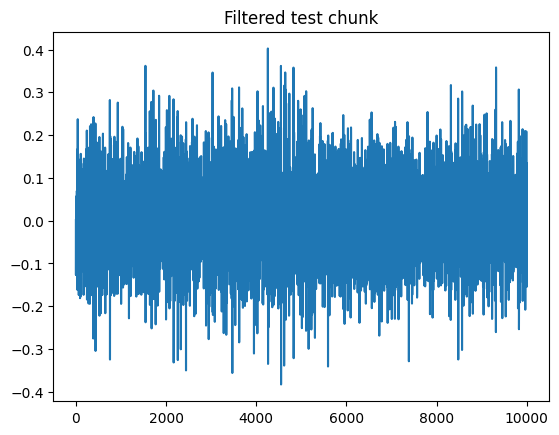

In [20]:

print(f"fs: {fs:.1f} Hz")
print(f"Nyquist: {fs/2:.1f} Hz")
print(f"high_cut valid: {3000 < fs/2}")

# then filter just a small chunk to test
test = df["raw_arm"].to_numpy(float)[:10000]
from scipy.signal import butter, filtfilt
nyq = fs / 2.0
b, a = butter(2, [300/nyq, 3000/nyq], btype="bandpass")
out = filtfilt(b, a, test)
print(f"filtered min: {out.min():.4f}, max: {out.max():.4f}")
plt.plot(out)
plt.title("Filtered test chunk")
plt.show()

In [21]:
def bandpass(x, fs, low, high, order=2):
    nyq = fs / 2.0
    b, a = butter(order, [low/nyq, high/nyq], btype="bandpass")
    return filtfilt(b, a, x)

def lowpass(x, fs, cutoff=40, order=3):
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype="low")
    return filtfilt(b, a, x)

Length: 5993955
Min: -2.0392, Max: 1.6598
Any NaN: False


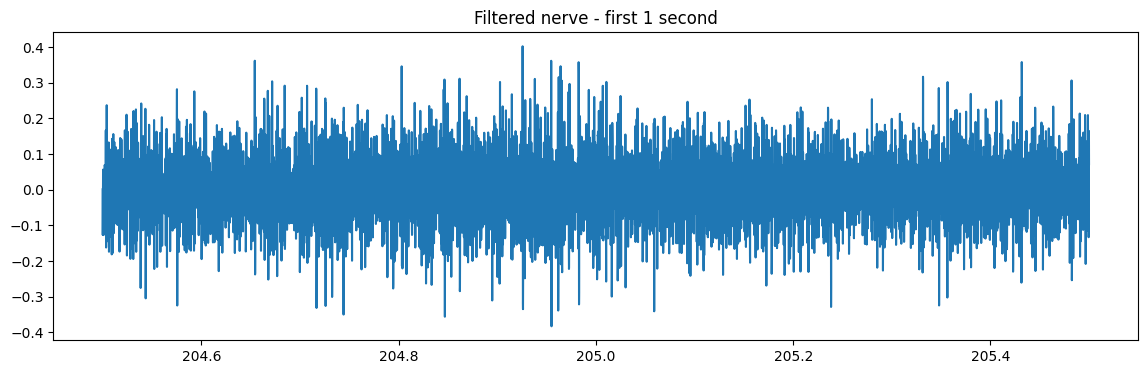

In [22]:
nerve_filt = bandpass(df["raw_arm"].to_numpy(float), fs, 300.0, 3000.0, order=2)

print(f"Length: {len(nerve_filt)}")
print(f"Min: {nerve_filt.min():.4f}, Max: {nerve_filt.max():.4f}")
print(f"Any NaN: {np.isnan(nerve_filt).any()}")

# plot a small window
plt.figure(figsize=(14,4))
plt.plot(df["time"].to_numpy()[:10000], nerve_filt[:10000])
plt.title("Filtered nerve - first 1 second")
plt.show()

In [ ]:
# nerve_raw = df["raw_arm"].to_numpy(float)
# print(f"NaNs in raw: {np.isnan(nerve_raw).sum()}")
# print(f"First NaN at index: {np.where(np.isnan(nerve_raw))[0][0]}")

# # clean it by dropping NaN rows from df first
# df_clean = df.dropna(subset=["raw_arm"]).reset_index(drop=True)
# print(f"Rows before: {len(df)}, after dropping NaN: {len(df_clean)}")

NaNs in raw: 0


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
low_cut=300.0
high_cut=3000.0
nerve_raw = df["raw_arm"].to_numpy(float)
 
nerve_filt = bandpass(nerve_raw, fs, low_cut, high_cut, order=2)
print(nerve_filt[:10])
nerve_filt

[nan nan nan nan nan nan nan nan nan nan]


array([nan, nan, nan, ..., nan, nan, nan])